# Notebook 11 — Rough Bergomi Calibration and Path Simulation

Simulates stock price and variance paths under the Rough Bergomi model
and calibrates parameters using the FNO surrogate.

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

from pricing.rbergomi_gpu import simulate_rbergomi_paths, rbergomi_iv_surface
from fno_model import MirrorPaddedFNO2d
from calibrate_fast import calibrate_rbergomi


Device: cuda


## 1. Simulate Rough Bergomi Paths

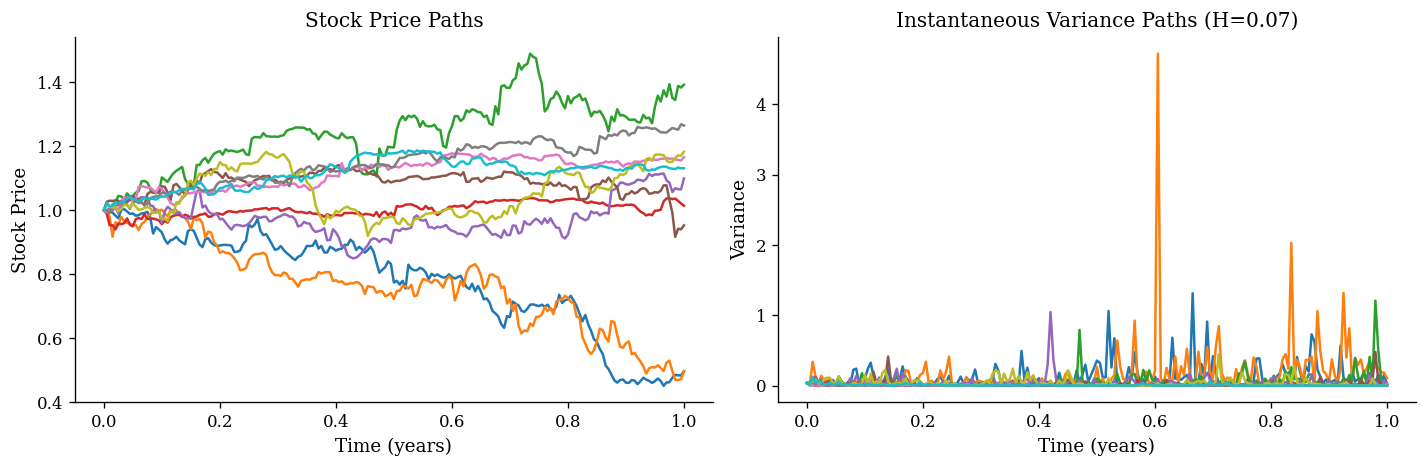

In [2]:
H = 0.07
params = torch.tensor([[0.04, H, 1.5, -0.7]], device=DEVICE, dtype=torch.float32)
T = 1.0
steps = 200
paths = 1000

# Simulate paths on GPU using Bennedsen hybrid scheme
S, V, t = simulate_rbergomi_paths(params, T, steps, paths, antithetic=True, device=DEVICE)
S_np = S[0].cpu().numpy()
V_np = V[0].cpu().numpy()
t_np = t.cpu().numpy()

# Plot paths
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_np, S_np[:10].T)
axes[0].set_title("Stock Price Paths")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Stock Price")

axes[1].plot(t_np, V_np[:10].T)
axes[1].set_title(f"Instantaneous Variance Paths (H={H})")
axes[1].set_xlabel("Time (years)")
axes[1].set_ylabel("Variance")
plt.tight_layout()
plt.show()


## 2. Load Rough Bergomi FNO Model and Calibrate

In [3]:
model_rb = MirrorPaddedFNO2d(param_dim=4).to(DEVICE)
model_rb.load_state_dict(torch.load("../artifacts/weights/fno_rbergomi_final_prod.pth", map_location=DEVICE))
model_rb.eval()

# Generate target IV surface
T_GRID = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
K_GRID = np.linspace(-0.5, 0.5, 11)

from calibrate import _load_normalizers, _fno_predict_real_iv, _make_spatial_input
_load_normalizers("rbergomi")
spatial = _make_spatial_input(T_GRID, K_GRID, DEVICE)
from calibrate import _param_norm
p_norm = _param_norm.transform_tensor(params)
with torch.no_grad():
    iv_target_t = _fno_predict_real_iv(model_rb, p_norm, spatial)
iv_target = iv_target_t.squeeze().cpu().numpy()

# Calibrate
res_rb = calibrate_rbergomi(model_rb, iv_target, T_GRID, K_GRID, max_iter=20)
print("Rough Bergomi Calibrated Params:")
print(f"  v0  = {res_rb['v0']:.4f} (true=0.04)")
print(f"  H   = {res_rb['H']:.4f} (true=0.07)")
print(f"  eta = {res_rb['eta']:.4f} (true=1.5)")
print(f"  rho = {res_rb['rho']:.4f} (true=-0.7)")
print(f"  MSE = {res_rb['final_mse']:.2e}")


Rough Bergomi Calibrated Params:
  v0  = 0.0100 (true=0.04)
  H   = 0.0400 (true=0.07)
  eta = 4.0000 (true=1.5)
  rho = -0.9500 (true=-0.7)
  MSE = 4.65e-04
